In [5]:
import os

os.environ['KAGGLE USERNAME'] = ''
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_fa7a94e89559844af941961e2ddd5e5f'

In [6]:
#importing dataset from kaggle

!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:00<00:00, 159MB/s]



In [7]:
#extracting

import zipfile

with zipfile.ZipFile('/content/fashionmnist.zip', 'r') as ref:
  ref.extractall()

In [9]:
#loading the csv data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/fashion-mnist_train.csv')
print(df.shape)
df.head()

(60000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


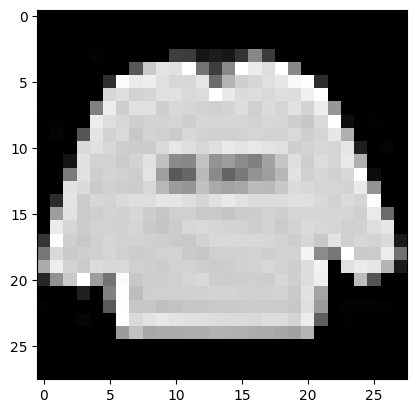

In [10]:
#displaying the images

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

image = np.reshape(X[0], (28, 28))

plt.imshow(image, cmap='gray')

In [11]:
#splitting the data into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#normalizing

X_train = X_train / 255.0
X_test = X_test / 255.0

X_test.shape

(12000, 784)

In [13]:
#model

import torch
from torch import nn

class model(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, features):
        out = self.network(features)
        return out



In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [15]:
m = model(X_train.shape[1])

In [16]:
#loss function and optimizer

lr=0.01
epochs=80
m=model(X_train.shape[1])

loss=nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(m.parameters(), lr=lr)

In [17]:
for i in range(epochs):
  y_pred=m(X_train)
  current_loss=loss(y_pred,y_train)

  optimizer.zero_grad()

  current_loss.backward()

  optimizer.step()

  print(f"  {current_loss} loss at epoch {i}")

  2.3074851036071777 loss at epoch 0
  2.1710965633392334 loss at epoch 1
  1.8332960605621338 loss at epoch 2
  1.5358062982559204 loss at epoch 3
  1.271746039390564 loss at epoch 4
  1.2001479864120483 loss at epoch 5
  1.064660906791687 loss at epoch 6
  0.9665544629096985 loss at epoch 7
  0.8930922150611877 loss at epoch 8
  0.8407958149909973 loss at epoch 9
  0.8226823806762695 loss at epoch 10
  0.7808688879013062 loss at epoch 11
  0.7313185334205627 loss at epoch 12
  0.7183469533920288 loss at epoch 13
  0.7183018326759338 loss at epoch 14
  0.6831201910972595 loss at epoch 15
  0.6542205214500427 loss at epoch 16
  0.647838294506073 loss at epoch 17
  0.6342681646347046 loss at epoch 18
  0.6121072173118591 loss at epoch 19
  0.6000558733940125 loss at epoch 20
  0.594015896320343 loss at epoch 21
  0.5811951756477356 loss at epoch 22
  0.5726058483123779 loss at epoch 23
  0.5658110976219177 loss at epoch 24
  0.5566453337669373 loss at epoch 25
  0.5435442924499512 loss 

In [18]:
from torch.utils.data import TensorDataset, DataLoader

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create TensorDataset for training and testing
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoader for training and testing
batch_size = 64 # You can adjust your batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Move model to device
m.to(device);

Using device: cpu


In [19]:
import torch
with torch.no_grad():

    for batch_feature, batch_label in train_loader:
        batch_feature = batch_feature.to(device)
        batch_label = batch_label.to(device)

        output = m(batch_feature)
        predicted = torch.argmax(output, dim=1)

        print(f"output: {output}")
        print(f"predicted: {predicted}")

Streaming output truncated to the last 5000 lines.
          9.0383e+00, -1.5048e+01,  9.6507e+00,  3.2206e+00,  1.5397e+01],
        [-2.3060e-01,  2.9668e+00,  7.5386e-01,  5.4132e+00,  4.9300e+00,
         -8.2176e+00,  2.6949e-01, -1.1607e+01, -2.6946e+00, -1.2314e+01],
        [-7.6104e+00, -1.1521e+01, -1.1280e+01, -1.3626e+01, -1.6453e+01,
          7.4722e+00, -1.6477e+01,  1.4118e+01,  4.4588e+00,  1.0874e+01],
        [ 1.7294e+00,  1.1753e+01, -2.1797e+00,  8.7037e-01,  7.7546e-01,
         -8.9957e+00, -1.5654e+00, -8.3495e+00, -4.4839e+00, -1.1550e+01],
        [ 1.0976e-01, -7.4151e-01,  3.3040e+00,  9.2302e-01,  2.0946e+00,
         -2.2403e+00,  4.5108e-01, -5.9257e+00, -8.5965e-01, -5.3288e+00],
        [-1.9793e+00, -1.2098e+01, -2.0480e+00, -6.2307e+00, -7.8440e+00,
          1.3444e+01, -4.3377e+00, -2.2384e+00,  2.1473e-01,  2.5288e+00],
        [ 3.9501e+00,  4.3391e-01, -1.8659e-01,  8.3590e+00, -1.1609e+00,
         -8.0031e+00,  2.3974e+00, -1.3394e+01, -2.5171

In [20]:
correct = 0
total = 0

with torch.no_grad():
    for batch_feature, batch_label in test_loader:
        output = m(batch_feature)
        predicted = torch.argmax(output, dim=1)

        total += batch_label.size(0)
        correct += (predicted == batch_label).sum().item()

print("Accuracy:", correct / total)

Accuracy: 0.8651666666666666


In [21]:
with torch.no_grad():
    for batch_feature, batch_label in test_loader:
        output = m(batch_feature)
        predicted = torch.argmax(output, dim=1)

        print("Actual:   ", batch_label)
        print("Predicted:", predicted)
        break

Actual:    tensor([7, 8, 8, 5, 9, 1, 2, 6, 6, 2, 5, 0, 7, 1, 6, 0, 6, 2, 9, 1, 2, 4, 8, 0,
        4, 9, 1, 0, 0, 5, 1, 6, 2, 7, 3, 4, 9, 9, 4, 8, 2, 6, 0, 2, 1, 5, 4, 4,
        6, 9, 1, 3, 2, 5, 8, 9, 5, 1, 1, 2, 3, 8, 3, 1])
Predicted: tensor([7, 8, 8, 5, 9, 1, 2, 3, 6, 2, 9, 0, 7, 1, 6, 0, 6, 2, 9, 1, 2, 8, 8, 0,
        4, 9, 1, 0, 0, 5, 3, 6, 2, 7, 3, 3, 9, 9, 4, 8, 2, 2, 3, 2, 1, 5, 4, 4,
        6, 9, 1, 3, 2, 5, 8, 9, 5, 1, 1, 2, 4, 8, 4, 1])
